In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("path to dataset file: ",path)

df=pd.read_csv(os.path.join(path,"AB_NYC_2019.csv"))
df.head()

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
path to dataset file:  /kaggle/input/new-york-city-airbnb-open-data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.shape

(48895, 16)

In [5]:
df.describe()
# df.describe(include='all') #This will show statistical data even for categorical values.

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


 Exploratory Data Analysis (EDA)

In [6]:
missing=df.isnull().sum()
missing

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


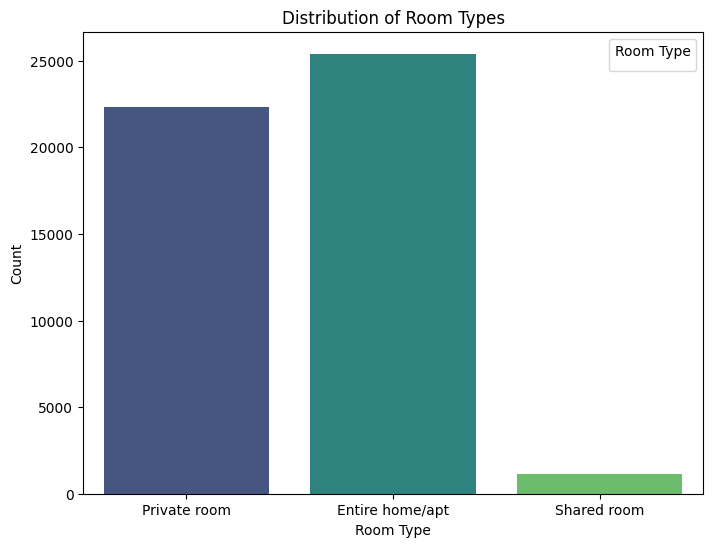

In [7]:
print(df['room_type'].value_counts())
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='room_type', data=df, hue='room_type', palette='viridis')

plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.legend(title='Room Type')
plt.show()

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

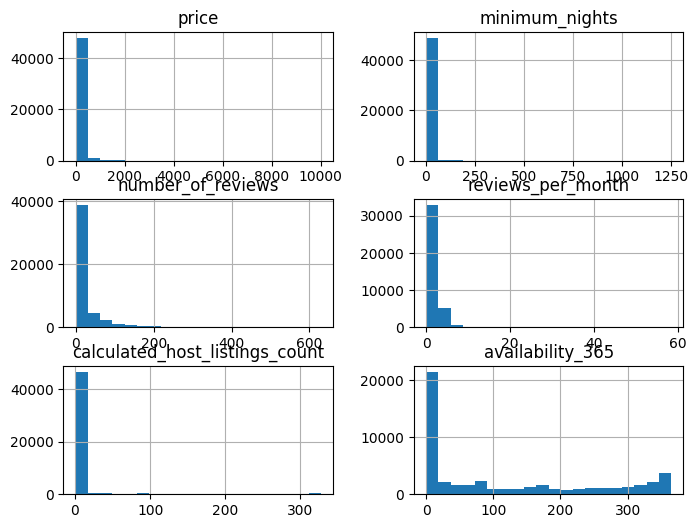

In [8]:
numerical_cols=["price","minimum_nights","number_of_reviews","reviews_per_month","calculated_host_listings_count","availability_365"]

df[numerical_cols].hist(bins=20,figsize=(8,6))

<Axes: xlabel='neighbourhood_group', ylabel='count'>

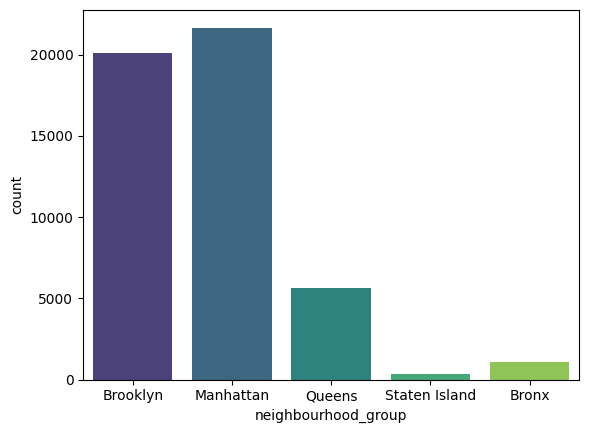

In [9]:
sns.countplot(x='neighbourhood_group',data=df,hue='neighbourhood_group',palette='viridis')


<Axes: xlabel='room_type', ylabel='price'>

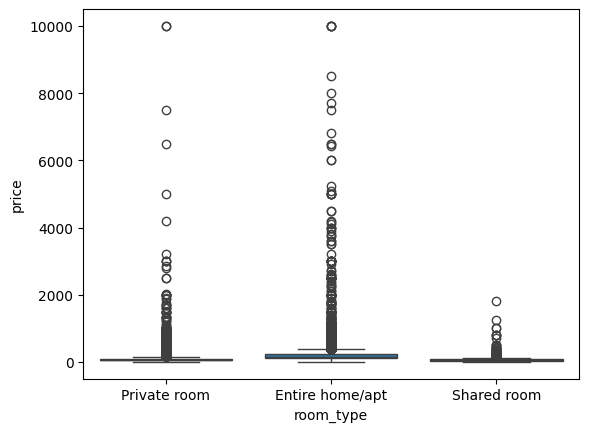

In [10]:
sns.boxplot(x='room_type',y='price',data=df)

<Axes: >

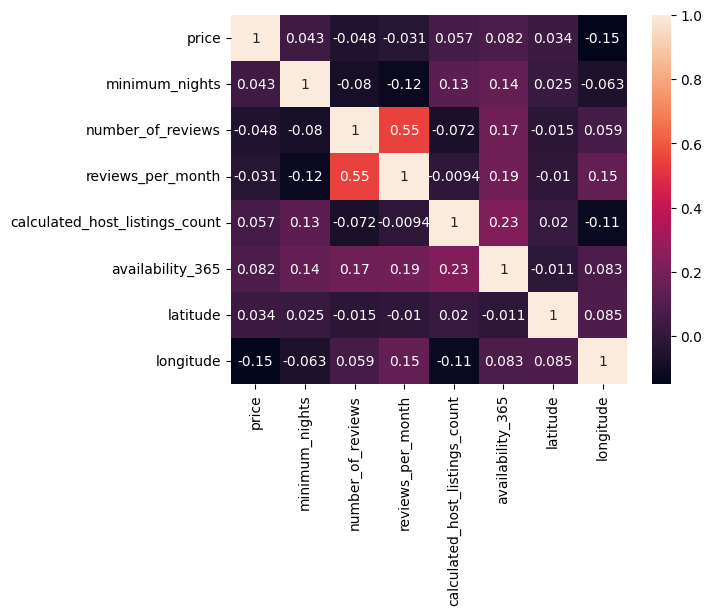

In [11]:
corr=df[numerical_cols+['latitude','longitude']].corr()
sns.heatmap(corr,annot=True)

<Axes: xlabel='longitude', ylabel='latitude'>

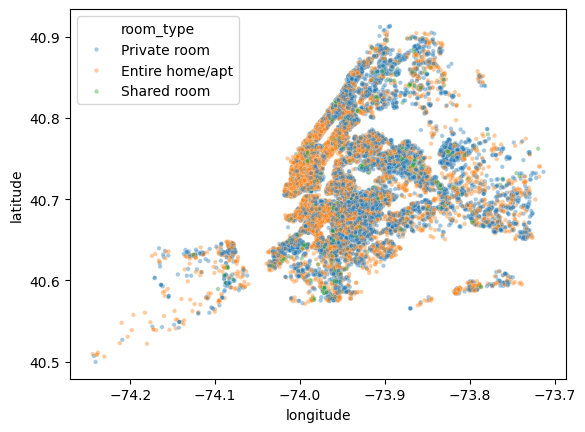

In [12]:
sns.scatterplot(y='latitude',x='longitude',data=df,hue='room_type',alpha=0.4,s=10)

**Data Cleaning & Feature Engineering**

In [13]:
df_clean=df.drop(columns=['name','id','host_id','host_name','last_review'])
df_clean.head()

df_clean['reviews_per_month']=df_clean['reviews_per_month'].fillna(0)

In [14]:
price_cap=df_clean['price'].quantile(0.99)
nights_cap=df_clean['minimum_nights'].quantile(0.99)

df_clean['price']=df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights']=df['minimum_nights'].clip(upper=nights_cap)

# df_clean=df_clean[df_clean['price']<=price_cap]
# df_clean=df_clean[df_clean['minimum_nights']<=nights_cap]

In [15]:
x=df_clean.drop(columns=['room_type'])
y=df_clean['room_type']

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42,stratify=y)
# stratisfy ensures that when we split the data it splits into original-proportion from all sections.

In [17]:
df_clean[numerical_cols].skew()

,0
price,2.776321
minimum_nights,2.360347
number_of_reviews,3.690635
reviews_per_month,3.300723
calculated_host_listings_count,7.933174
availability_365,0.763408


In [18]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [19]:
numerical_cols=['latitude','longitude','price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
categorical_cols=['neighbourhood_group','neighbourhood']

# ('skewness',PowerTransformer(method='yeo-johnson')),

#1. Pipeline -> For Numeric Columns
numeric_pipeline=Pipeline(steps=[
('impute', SimpleImputer(strategy="median")),
('scale',StandardScaler())
])

#2. Pipeline -> For Categorical Columns

categorical_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ("numerical",numeric_pipeline,numerical_cols),
    ("categorical",categorical_pipeline,categorical_cols)
])

In [20]:
preprocessor


ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

**SMOTE (Synthetic Minority Oversampling)** **->** For Class **IMBalance**
--------------------------------------------------------
1. High chances of Overfitting
2. Data leakage

In [21]:
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [22]:
# class_weight="Balanced" tells the model to pay more attention to the minority class
# or rare class (Shared Room)
# but the problem is GradintBossting doesnt support class weight so we left it as it is.

models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced",random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest"       : RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])

    # Accuracy alone can be misleading on imbalanced classes, so we use macro f1
    # both: plain accuracy and macro f1 (which treats every class equally)

    accuracy = cross_val_score(pipe, X_train, y_train,cv=3,scoring="accuracy")
    macrof1 = cross_val_score(pipe, X_train, y_train,cv=3,scoring="f1_macro")

    print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")

Logistic Regression -> Accuracy: 0.659 , F1: 0.522
Decision Tree -> Accuracy: 0.782 , F1: 0.647
Random Forest -> Accuracy: 0.851 , F1: 0.715
Gradient Boosting -> Accuracy: 0.850 , F1: 0.705


In [23]:
lrcv_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegressionCV(class_weight='balanced', cv=3, random_state=42, max_iter=1000))
])

# Fit the model
lrcv_pipe.fit(X_train, y_train)

# Evaluate
train_acc = lrcv_pipe.score(X_train, y_train)
test_acc = lrcv_pipe.score(X_test, y_test)

print(f"LogisticRegressionCV Train Accuracy: {train_acc:.3f}")
print(f"LogisticRegressionCV Test Accuracy: {test_acc:.3f}")

LogisticRegressionCV Train Accuracy: 0.666
LogisticRegressionCV Test Accuracy: 0.669


In [25]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
     ("classifier",RandomForestClassifier(class_weight='balanced'))
     ])

param_distribution={
    "classifier__n_estimators":[100,200,150,300],
    "classifier__max_depth":[8,12,15,20,None],
    "classifier__min_samples_split":[2,5,10],
}

search=RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
)

search.fit(X_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['latitude',
                                                                                'longitude',
                                                                                'price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365']),
                                                                              ('categ...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encode',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [27]:
print("Best Parameters: ",search.best_params_)
print("Best CV Macro-F1 Score: ",search.best_score_)

Best Parameters:  {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
Best CV Macro-F1 Score:  0.7304337156110319


In [28]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix

best_pipeline=search.best_estimator_
y_pred=best_pipeline.predict(X_test)

print("Test Accuracy: ",accuracy_score(y_test,y_pred))
print("Test F1 Score: ",f1_score(y_test,y_pred,average='macro'))

Test Accuracy:  0.8557882994546356
Test F1 Score:  0.7421483135079322


<Axes: >

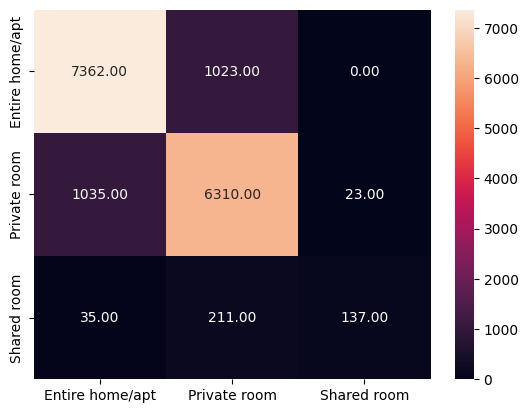

In [31]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",
            xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

In [33]:
import joblib

joblib.dump(best_pipeline,'model_pipeline.pkl',compress=3)

['model_pipeline.pkl']